In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

In [ ]:
# 그래프 시각화에서 한글 깨짐 방지 
if platform.system() == 'Darwins':
    # MAC 사용자
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
# 마이너스 기호 깨짐 방지 
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 신용카드 사기 거래 데이터셋 로드 
df = pd.read_csv('../data/creditcard.csv')
df.head()

In [ ]:
df.info()

In [ ]:
# 결측치의 개수를 확인 
df.isna().sum().sum()

In [ ]:
df[ ['Time', 'Amount'] ].describe()

In [ ]:
# Time 컬럼의 데이터의 의미는 'Sec' --> 'Hour'
# 24시간 체계로 변환 
df['Hour'] = (df['Time'] // 3600) % 24

In [ ]:
df['Hour'].describe()

In [ ]:
# 정상거래와 이상거래의 빈도수 체크 
df['Class'].value_counts()

In [ ]:
# 밀도 그래프 시각화 
plt.figure(figsize=(12, 8))

sns.kdeplot( df.loc[ df['Class'] == 0, 'Hour' ], label = '정상 결제(0)', fill=True, alpha=0.3 )

sns.kdeplot( df.loc[ df['Class'] == 1, 'Hour' ], label = '이상 결제(1)', fill=True, alpha=0.3, color='red' )

plt.title('시간대 별 정상 결제 / 이상 결제')
plt.xlabel('결제 시간대 (0~ 23시)')
plt.ylabel('밀도')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 절대량 시각화 

plt.figure(figsize=(12, 8))

sns.histplot( df.loc[ df['Class'] == 1, ], x = 'Hour', bins = 24, color='red', kde = True )

plt.xlabel('결제 시간대')
plt.ylabel('사기 결제 건수')
plt.show()

In [ ]:
# 결제 시간대 별 전체 결제 건수 대비 사기 결제 건수의 비율
# 0시  ->   사기거래 건수(70) / 전체 거래 건수(100) * 100 --> 70%
# 정상 거래 (0)  / 사기 거래 (1) -> 모든 데이터를 더하면? -> 사기 거래의 건수
# 전체 데이터의 개수와 나눠준다? -> 평균 (mean)
group_df = df.groupby('Hour')['Class'].mean() * 100
group_df

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x = group_df.index, y = group_df.values, color = 'red')
plt.xlabel('결제 시간대')
plt.ylabel('사기일 확률(%)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# 시간 데이터와 class 는 학습 데이터에서 제외 
x = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

In [ ]:
scaler = StandardScaler()
x['Amount'] = scaler.fit_transform(x[['Amount']])

In [ ]:
# 학습 / 검증 데이터로 데이터 분할 
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print(f"Train Data에서 정상 거래 건수 : {sum(y_train == 0)} 사기 거래 건수 : {sum(y_train == 1)}")

In [ ]:
# 일반 모델 -> 기본값을 사용
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

In [ ]:
# 데이터의 불균형 문제를 해결하기 위해 모델에서 class_weight 매개변수를 수정 
model2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

In [ ]:
print(f"일반 모델")
print(classification_report(y_test, pred1))
print(f"밸런스 모델")
print(classification_report(y_test, pred2))

In [ ]:
# 사기 거래 데이터에서 SMOTE를 이용하여 소수의 데이터를 늘려준다. -> 1번 모델을 이용해서 학습, 예측

from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
print(f"SMOTE 후 정상 거래 개수 : {sum(y_train_sm == 0)}, 사기 거래 건수 : {sum(y_train_sm == 1)}")

In [ ]:
# SMOTE를 이용하여 데이터의 비율을 맞추고 모델1에 학습 및 예측 -> 검증 
model1.fit(X_train_sm, y_train_sm)

In [ ]:
pred3 = model1.predict(X_test)

In [ ]:
print('SMOTE 후 일반 모델')
print(classification_report(y_test, pred3))

In [ ]:
# SHAP value 확인 ( shap 라이브러리 설치 )
# !pip install shap

In [ ]:
import shap

In [38]:
# SHAP 설명기 -> 선형 모델용 LinearExplainer
explainer = shap.LinearExplainer(model2, X_train)

# 분석할 타켓 데이터를 선정 -> 사기 결제 데이터중 첫번째 데이터 선택 
target_data = X_test[y_test == 1].iloc[[0]]
target_data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
77348,-1.271244,2.462675,-2.851395,2.32448,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,-4.881143,...,0.652941,0.081931,-0.221348,-0.523582,0.224228,0.756335,0.6328,0.250187,-0.353189,15.0


In [39]:
# SHAP value 계산
shap_value = explainer.shap_values(target_data)
shap_value

array([[-0.93230791,  1.74182547, -1.33563411,  2.53461772, -1.41677725,
         0.64065525,  2.33896814, -0.66178745,  0.96291341,  6.41967343,
         1.62248177,  6.30607212, -0.27857955,  9.75837116, -0.07969563,
         5.81763398,  7.57862585,  1.10440136,  0.49338321, -0.98730861,
         0.04078352,  0.08965337, -0.18425904,  0.02957783,  0.01047422,
        -0.24412983, -0.30030121,  0.26144103, -0.81460942,  0.03480978]])

c:\Users\ekfla\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\plots\_waterfall.py:638: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\ekfla\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


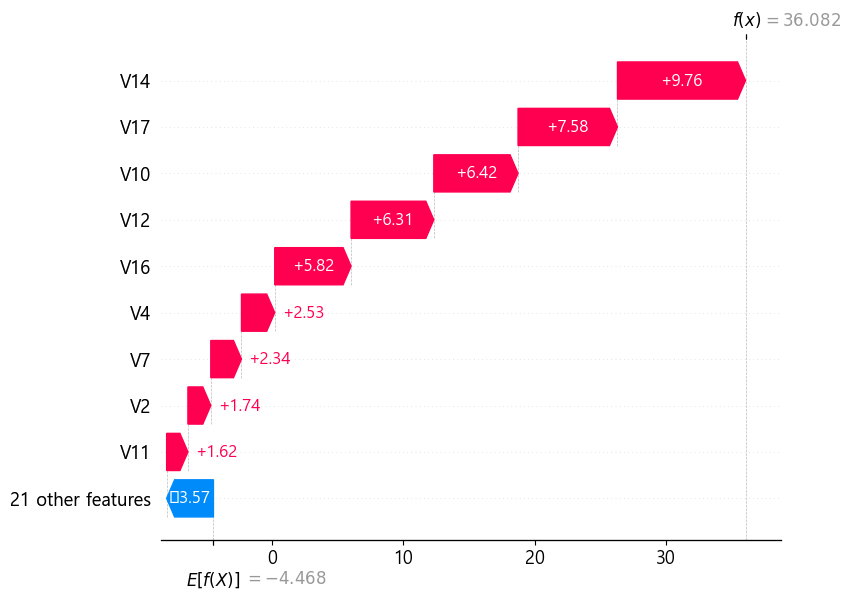

In [40]:
# 폭포수 챠트 
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_value[0], feature_names= x.columns)

In [ ]:
# LIME 라이브러리 설치 
# !pip install lime

In [43]:
import lime.lime_tabular as lime

# lime 설명기 초기화(객체 생성)
explainer_lime = lime.LimeTabularExplainer(
    training_data= X_train.values, 
    feature_names= x.columns, 
    class_names = ['정상결제(0)', '사기결제(1)'], 
    mode = 'classification', 
    random_state=42
)

In [ ]:
# 분석할 타켓 데이터를 지정 
target_data = X_test[y_test == 1].iloc[1]
target_data

In [47]:
# LIME 설명을 할수 있는 데이터를 출력 
exp = explainer_lime.explain_instance(
    data_row= target_data.values, 
    predict_fn=model2.predict_proba, 
    num_features=5
)

c:\Users\ekfla\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


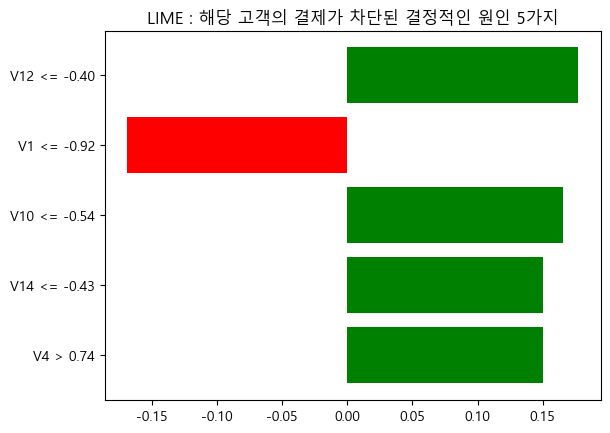

In [50]:
exp.as_pyplot_figure()
plt.title("LIME : 해당 고객의 결제가 차단된 결정적인 원인 5가지")
plt.show()

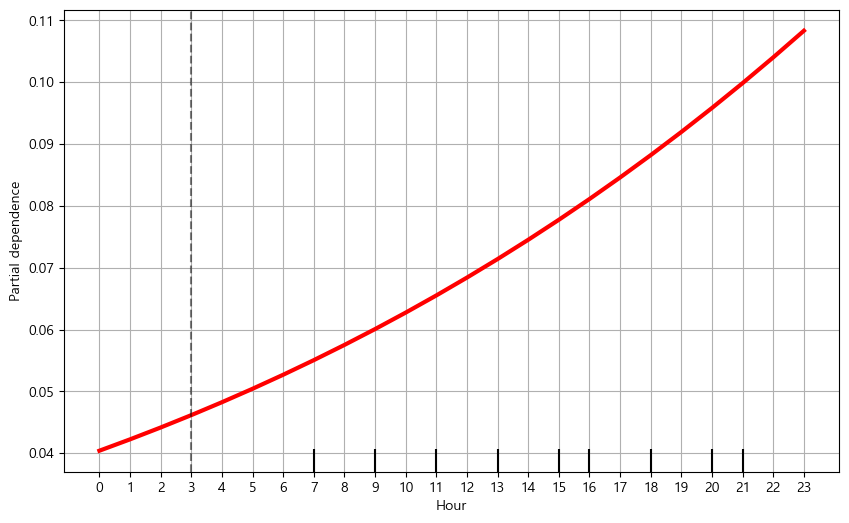

In [51]:
# PDP -> 특정 컬럼이 변화할때 예측 값에 대해 영향력을 확인 
from sklearn.inspection import PartialDependenceDisplay

# 결제 시간대가 사기 거래 판정 확률에 미치는 영향 

fig, ax = plt.subplots(figsize = (10, 6))

# PDP 그래프 생성 
pdp_display = PartialDependenceDisplay.from_estimator(
    estimator= model2, 
    X = X_train, 
    features = ['Hour'], 
    kind = 'average', 
    ax = ax, 
    line_kw={'color' : 'red', 'linewidth' : 3}
)

# 보조선 추가 
plt.axvline( x = 3, color='black', linestyle='--', alpha = 0.5 )
plt.xticks(range(0, 24))
plt.grid()
plt.show()

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced_subsample')
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

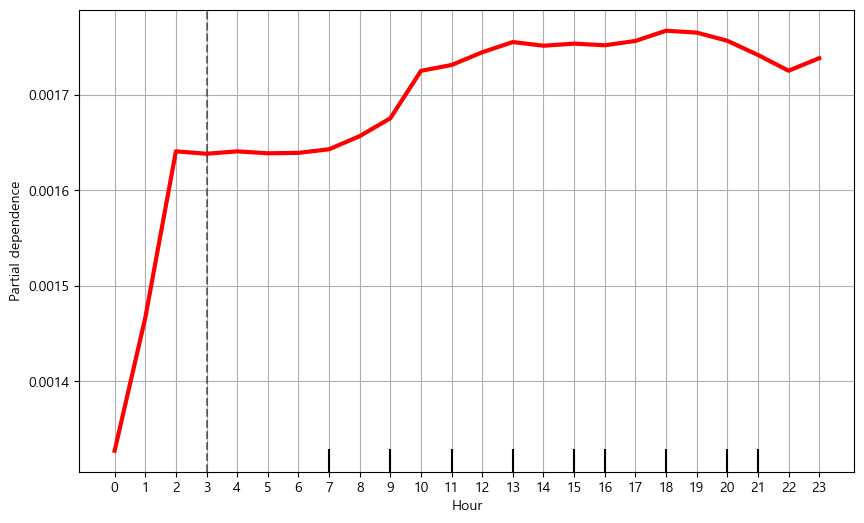

In [54]:
fig, ax = plt.subplots(figsize = (10, 6))

# PDP 그래프 생성 
pdp_display = PartialDependenceDisplay.from_estimator(
    estimator= rf, 
    X = X_train, 
    features = ['Hour'], 
    kind = 'average', 
    ax = ax, 
    line_kw={'color' : 'red', 'linewidth' : 3}
)

# 보조선 추가 
plt.axvline( x = 3, color='black', linestyle='--', alpha = 0.5 )
plt.xticks(range(0, 24))
plt.grid()
plt.show()